# Solar Power Output Prediction

**Dataset:** Solar Power Generation Data (Two Indian Solar Plants, May–June 2020)  
**Problem:** Predict AC Power output from weather and irradiance features  
**Models:** Linear Regression · Random Forest · XGBoost · Transformer Encoder  


---
## Section 1 — Imports and Setup

In [1]:
# ── Standard libraries ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn ──────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, learning_curve

# ── XGBoost ───────────────────────────────────────────────────────────
from xgboost import XGBRegressor

# ── PyTorch (Transformer) ─────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Global settings ───────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_style('whitegrid')

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print('All libraries imported successfully.')

Using device: cuda
All libraries imported successfully.


---
## Section 2 — Exploratory Data Analysis (EDA)

### 2.1 Load Raw Data

In [2]:
# Loading the dataset — four CSV files
plant1_gen     = pd.read_csv('Plant_1_Generation_Data.csv')
plant1_weather = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')
plant2_gen     = pd.read_csv('Plant_2_Generation_Data.csv')
plant2_weather = pd.read_csv('Plant_2_Weather_Sensor_Data.csv')

# Parse timestamps
# NOTE: Plant 1 generation uses dayfirst=True format
plant1_gen['DATE_TIME']     = pd.to_datetime(plant1_gen['DATE_TIME'], dayfirst=True)
plant1_weather['DATE_TIME'] = pd.to_datetime(plant1_weather['DATE_TIME'])
plant2_gen['DATE_TIME']     = pd.to_datetime(plant2_gen['DATE_TIME'])
plant2_weather['DATE_TIME'] = pd.to_datetime(plant2_weather['DATE_TIME'])

print('=== Plant 1 Generation ===')
display(plant1_gen.head(3))
print('\n=== Plant 1 Weather ===')
display(plant1_weather.head(3))

=== Plant 1 Generation ===


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0



=== Plant 1 Weather ===


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0


### 2.2 Dataset Inspection

In [3]:
for name, df in [
    ('Plant 1 Generation', plant1_gen),
    ('Plant 1 Weather',    plant1_weather),
    ('Plant 2 Generation', plant2_gen),
    ('Plant 2 Weather',    plant2_weather)
]:
    print(f"\n{'='*50}")
    print(f'Dataset : {name}')
    print(f'Shape   : {df.shape}')
    print(f'Dates   : {df["DATE_TIME"].min()} -> {df["DATE_TIME"].max()}')
    print(f'Nulls   : {df.isnull().sum().sum()} total missing values')


Dataset : Plant 1 Generation
Shape   : (68778, 7)
Dates   : 2020-05-15 00:00:00 -> 2020-06-17 23:45:00
Nulls   : 0 total missing values

Dataset : Plant 1 Weather
Shape   : (3182, 6)
Dates   : 2020-05-15 00:00:00 -> 2020-06-17 23:45:00
Nulls   : 0 total missing values

Dataset : Plant 2 Generation
Shape   : (67698, 7)
Dates   : 2020-05-15 00:00:00 -> 2020-06-17 23:45:00
Nulls   : 0 total missing values

Dataset : Plant 2 Weather
Shape   : (3259, 6)
Dates   : 2020-05-15 00:00:00 -> 2020-06-17 23:45:00
Nulls   : 0 total missing values


### 2.3 Merge and Combine Plants

In [4]:
# Merge generation + weather for each plant on DATE_TIME and PLANT_ID
plant1 = pd.merge(plant1_gen, plant1_weather, on=['DATE_TIME', 'PLANT_ID'], how='inner')
plant2 = pd.merge(plant2_gen, plant2_weather, on=['DATE_TIME', 'PLANT_ID'], how='inner')

# Combine both plants
data = pd.concat([plant1, plant2], ignore_index=True)
data = data.sort_values('DATE_TIME').reset_index(drop=True)

print(f'Combined shape: {data.shape}')
display(data.head())

Combined shape: (136472, 11)


,DATE_TIME,PLANT_ID,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.000000,6.259559e+06,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15,4136001,Et9kgGMDl729KT4,0.0,0.0,269.933333,1.704250e+06,iq8k7ZNt4Mwm3w0,27.004764,25.060789,0.0
2,2020-05-15,4136001,IQ2d7wF4YD8zU1Q,0.0,0.0,3177.000000,1.994153e+07,iq8k7ZNt4Mwm3w0,27.004764,25.060789,0.0
3,2020-05-15,4136001,LYwnQax7tkwH5Cb,0.0,0.0,1872.500000,1.794959e+09,iq8k7ZNt4Mwm3w0,27.004764,25.060789,0.0
4,2020-05-15,4136001,LlT2YUhhzqhg5Sw,0.0,0.0,1094.357143,2.825928e+08,iq8k7ZNt4Mwm3w0,27.004764,25.060789,0.0


### 2.4 Data Cleaning

In [5]:
# Missing value audit
print('Missing values per column:')
print(data.isnull().sum())

# Remove any missing values and duplicates
data = data.dropna()
data = data.drop_duplicates()
print(f'\nShape after cleaning: {data.shape}')

Missing values per column:
DATE_TIME              0
PLANT_ID               0
SOURCE_KEY_x           0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
SOURCE_KEY_y           0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64

Shape after cleaning: (136472, 11)


### 2.5 Missing Data Visualisation

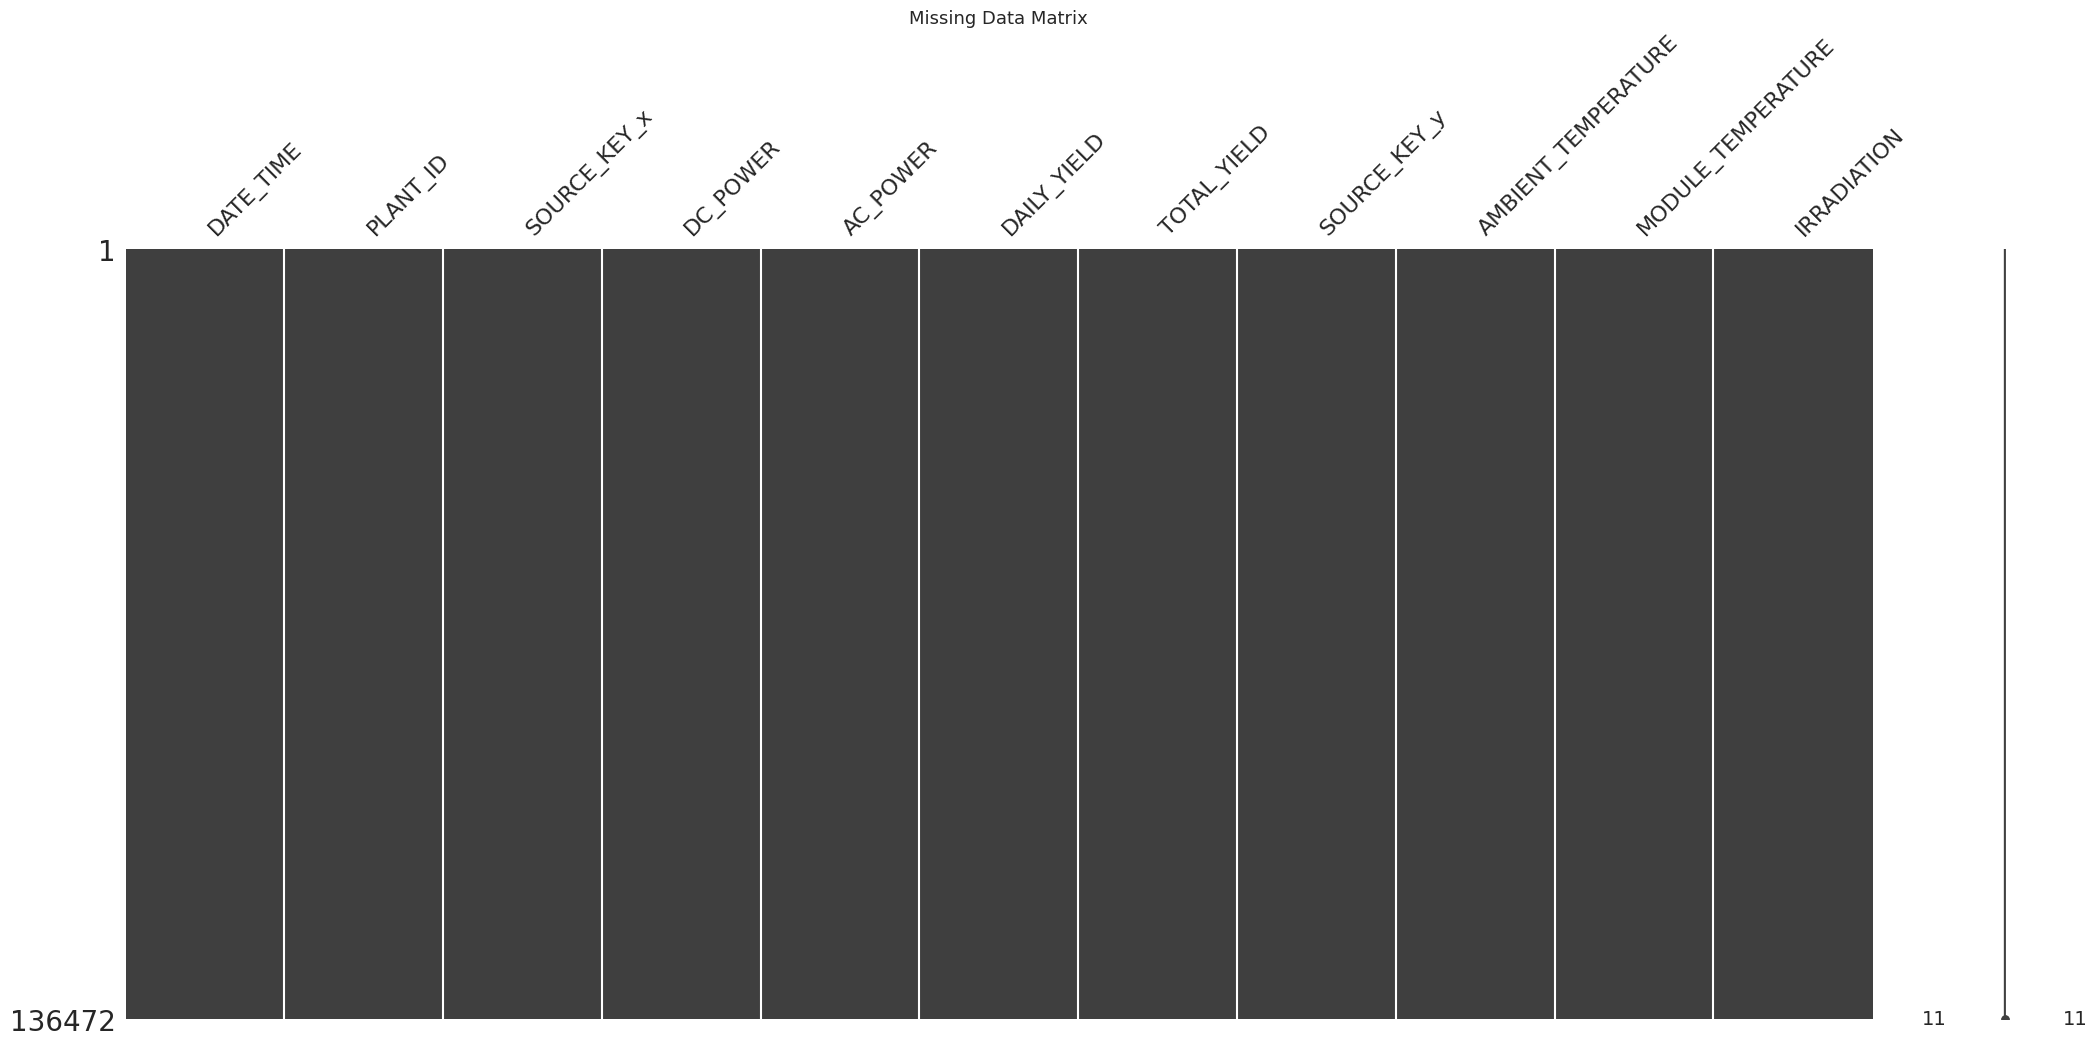

In [6]:
# Missingno matrix — confirms no missing values
msno.matrix(data)
plt.title('Missing Data Matrix')
plt.show()

### 2.6 Descriptive Statistics

In [7]:
print('Descriptive Statistics:')
display(data[['DC_POWER', 'AC_POWER', 'DAILY_YIELD',
              'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']].describe().round(3))

Descriptive Statistics:


,DC_POWER,AC_POWER,DAILY_YIELD,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE
count,136472.000,136472.000,136472.000,136472.000,136472.000,136472.000
mean,1708.374,274.790,3295.366,0.231,26.763,31.921
std,3222.079,380.180,3035.313,0.306,3.897,11.804
min,0.000,0.000,0.000,0.000,20.399,18.140
25%,0.000,0.000,28.286,0.000,23.638,22.412
50%,5.993,3.493,2834.643,0.026,25.908,26.414
75%,1155.595,532.569,5992.000,0.443,29.267,40.779
max,14471.125,1410.950,9873.000,1.222,39.182,66.636


### 2.7 Feature Distributions — Figure 1

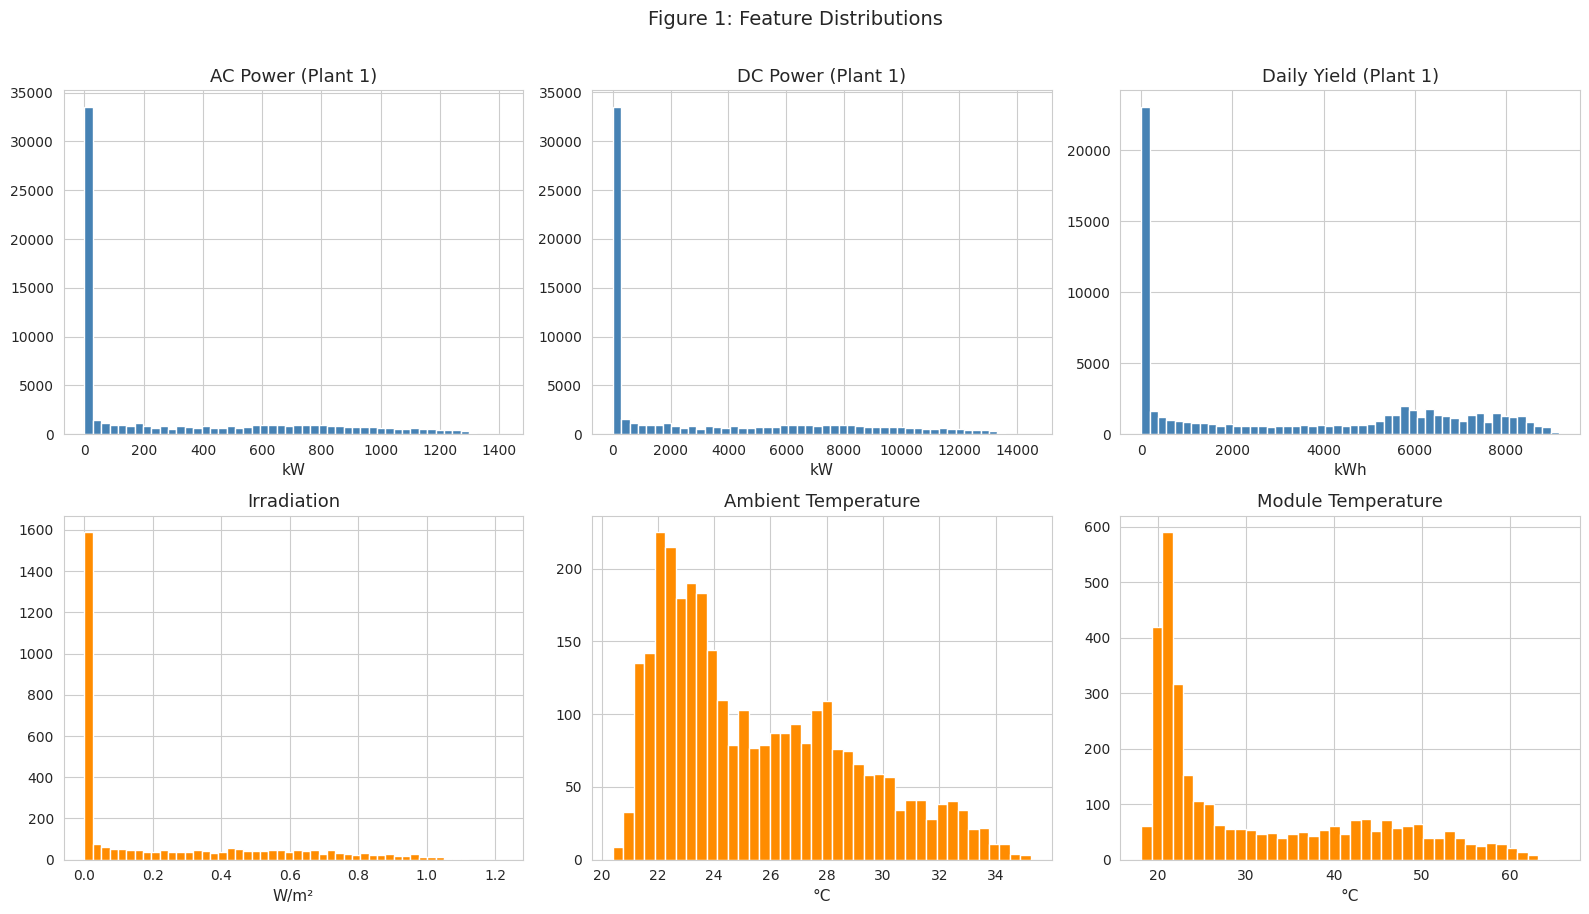

In [8]:
# Plant-level aggregation for distribution plots
p1_plot = plant1_gen.copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

p1_plot['AC_POWER'].hist(bins=50, ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('AC Power (Plant 1)'); axes[0,0].set_xlabel('kW')

p1_plot['DC_POWER'].hist(bins=50, ax=axes[0,1], color='steelblue', edgecolor='white')
axes[0,1].set_title('DC Power (Plant 1)'); axes[0,1].set_xlabel('kW')

p1_plot['DAILY_YIELD'].hist(bins=50, ax=axes[0,2], color='steelblue', edgecolor='white')
axes[0,2].set_title('Daily Yield (Plant 1)'); axes[0,2].set_xlabel('kWh')

plant1_weather['IRRADIATION'].hist(bins=50, ax=axes[1,0], color='darkorange', edgecolor='white')
axes[1,0].set_title('Irradiation'); axes[1,0].set_xlabel('W/m²')

plant1_weather['AMBIENT_TEMPERATURE'].hist(bins=40, ax=axes[1,1], color='darkorange', edgecolor='white')
axes[1,1].set_title('Ambient Temperature'); axes[1,1].set_xlabel('°C')

plant1_weather['MODULE_TEMPERATURE'].hist(bins=40, ax=axes[1,2], color='darkorange', edgecolor='white')
axes[1,2].set_title('Module Temperature'); axes[1,2].set_xlabel('°C')

plt.suptitle('Figure 1: Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.8 AC Power Over Time — Figure 2

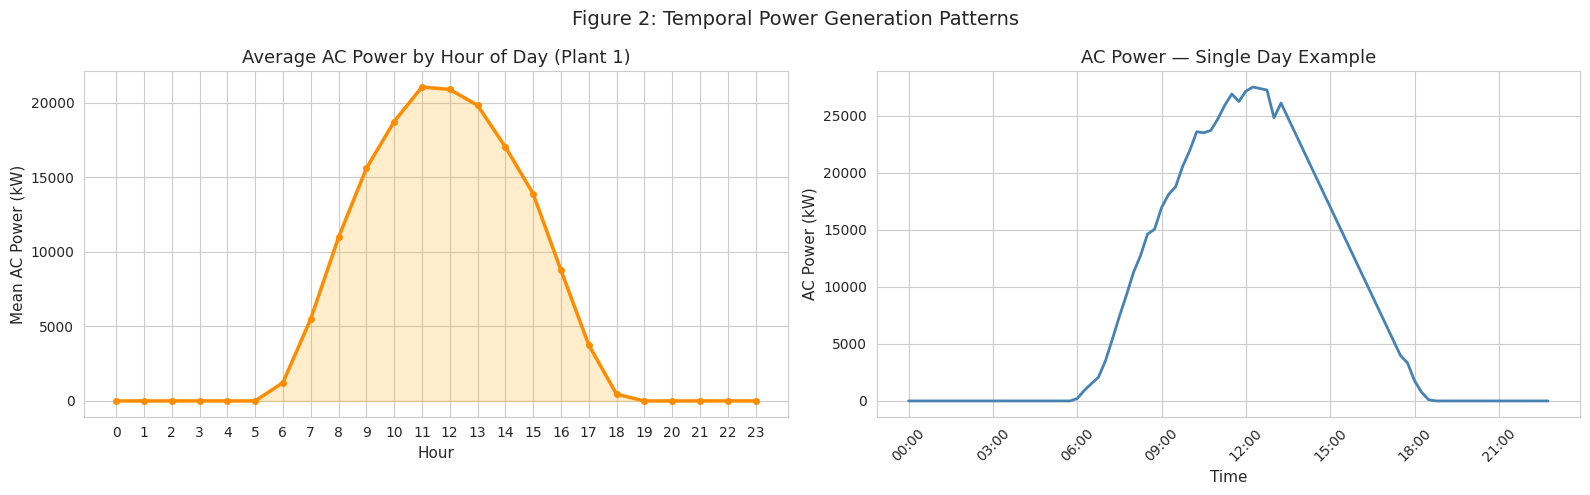

In [9]:
# Aggregate to plant level for cleaner temporal view
p1_agg    = plant1_gen.groupby('DATE_TIME')[['AC_POWER']].sum().reset_index()
hourly_avg = p1_agg.groupby(p1_agg['DATE_TIME'].dt.hour)['AC_POWER'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(hourly_avg.index, hourly_avg.values, color='darkorange', linewidth=2.5, marker='o', markersize=4)
axes[0].fill_between(hourly_avg.index, hourly_avg.values, alpha=0.2, color='orange')
axes[0].set_title('Average AC Power by Hour of Day (Plant 1)')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Mean AC Power (kW)'); axes[0].set_xticks(range(0, 24))

single_day = p1_agg[p1_agg['DATE_TIME'].dt.date == p1_agg['DATE_TIME'].dt.date.unique()[5]]
axes[1].plot(single_day['DATE_TIME'], single_day['AC_POWER'], color='steelblue', linewidth=2)
axes[1].set_title('AC Power — Single Day Example')
axes[1].set_xlabel('Time'); axes[1].set_ylabel('AC Power (kW)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Figure 2: Temporal Power Generation Patterns', fontsize=14)
plt.tight_layout()
plt.savefig('fig2_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.9 Irradiation vs AC Power — Figure 3

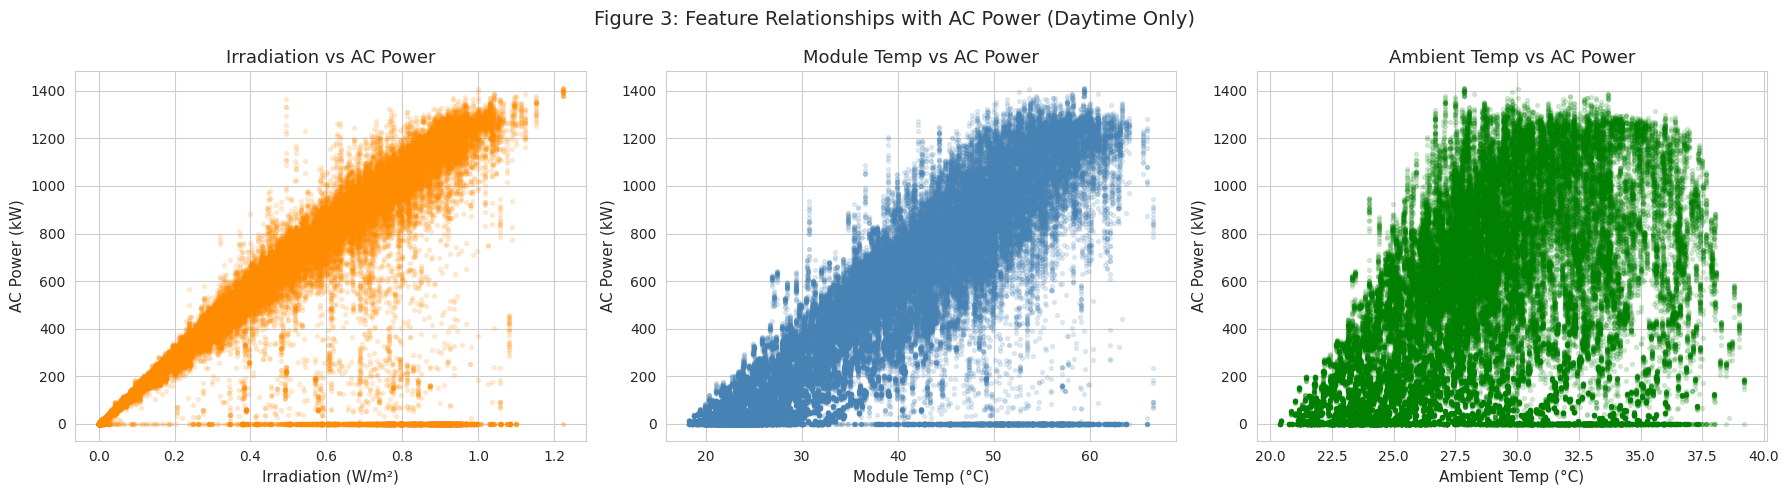

In [10]:
# Filter to daytime only for scatter plots
data_day = data[data['IRRADIATION'] > 0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(data_day['IRRADIATION'], data_day['AC_POWER'], alpha=0.15, s=8, color='darkorange')
axes[0].set_title('Irradiation vs AC Power'); axes[0].set_xlabel('Irradiation (W/m²)'); axes[0].set_ylabel('AC Power (kW)')

axes[1].scatter(data_day['MODULE_TEMPERATURE'], data_day['AC_POWER'], alpha=0.15, s=8, color='steelblue')
axes[1].set_title('Module Temp vs AC Power'); axes[1].set_xlabel('Module Temp (°C)'); axes[1].set_ylabel('AC Power (kW)')

axes[2].scatter(data_day['AMBIENT_TEMPERATURE'], data_day['AC_POWER'], alpha=0.15, s=8, color='green')
axes[2].set_title('Ambient Temp vs AC Power'); axes[2].set_xlabel('Ambient Temp (°C)'); axes[2].set_ylabel('AC Power (kW)')

plt.suptitle('Figure 3: Feature Relationships with AC Power (Daytime Only)', fontsize=14)
plt.tight_layout()
plt.savefig('fig3_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.10 Correlation Heatmap — Figure 4

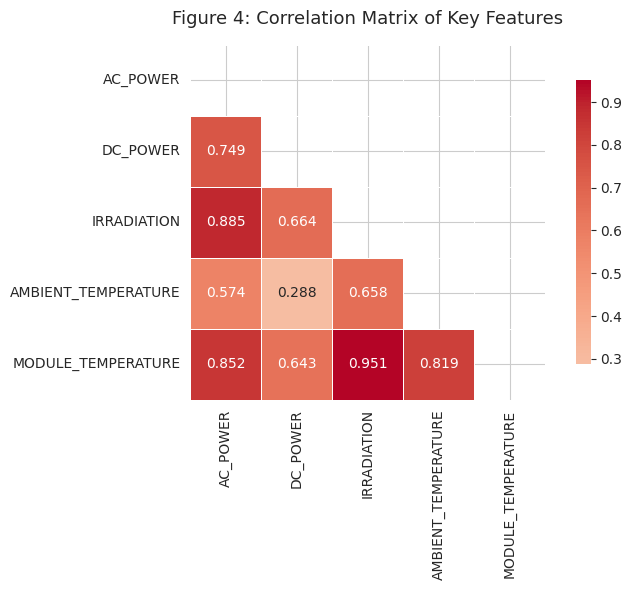


Correlations with AC_POWER:
AC_POWER               1.0000
IRRADIATION            0.8848
MODULE_TEMPERATURE     0.8524
DC_POWER               0.7486
AMBIENT_TEMPERATURE    0.5742
Name: AC_POWER, dtype: float64


In [11]:
corr_cols = ['AC_POWER', 'DC_POWER', 'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']
corr      = data[corr_cols].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, mask=mask, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Figure 4: Correlation Matrix of Key Features', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('fig4_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelations with AC_POWER:')
print(corr['AC_POWER'].sort_values(ascending=False).round(4))

---
## Section 3 — Preprocessing & Feature Engineering

### 3.1 Feature Engineering

In [12]:
# Sort chronologically
data = data.sort_values('DATE_TIME').reset_index(drop=True)

# Basic time features
data['hour']    = data['DATE_TIME'].dt.hour
data['day']     = data['DATE_TIME'].dt.day
data['month']   = data['DATE_TIME'].dt.month
data['weekday'] = data['DATE_TIME'].dt.weekday

# Cyclical encoding of hour — preserves circular continuity
# (23:45 and 00:00 are adjacent, not maximally different)
data['HOUR_FLOAT'] = data['DATE_TIME'].dt.hour + data['DATE_TIME'].dt.minute / 60
data['HOUR_SIN']   = np.sin(2 * np.pi * data['HOUR_FLOAT'] / 24)
data['HOUR_COS']   = np.cos(2 * np.pi * data['HOUR_FLOAT'] / 24)
data['DAY_OF_YEAR']= data['DATE_TIME'].dt.dayofyear

print('New features added: HOUR_SIN, HOUR_COS, DAY_OF_YEAR')
display(data[['DATE_TIME', 'HOUR_FLOAT', 'HOUR_SIN', 'HOUR_COS', 'DAY_OF_YEAR']].head())

New features added: HOUR_SIN, HOUR_COS, DAY_OF_YEAR


,DATE_TIME,HOUR_FLOAT,HOUR_SIN,HOUR_COS,DAY_OF_YEAR
0,2020-05-15,0.0,0.0,1.0,136
1,2020-05-15,0.0,0.0,1.0,136
2,2020-05-15,0.0,0.0,1.0,136
3,2020-05-15,0.0,0.0,1.0,136
4,2020-05-15,0.0,0.0,1.0,136


### 3.2 Feature and Target Selection

In [13]:
# Features for classical ML models
features = [
    'AMBIENT_TEMPERATURE',
    'MODULE_TEMPERATURE',
    'IRRADIATION',
    'HOUR_SIN',     # cyclical — replaces raw 'hour'
    'HOUR_COS',
    'DAY_OF_YEAR',
    'hour',         # kept for compatibility
    'day',
    'month',
    'weekday'
]

target = 'AC_POWER'

x = data[features]
y = data[target]
print(f'Feature matrix shape: {x.shape}')
print(f'Target shape        : {y.shape}')

Feature matrix shape: (136472, 10)
Target shape        : (136472,)


### 3.3 Train / Test Split
> A **temporal (chronological) split** is used — NOT random `train_test_split` —
> to prevent data leakage in time-series data.
> Using random split on time-series data allows future observations to
> inform past predictions, producing artificially optimistic metrics.

In [14]:
# Time-based split: 80% train / 20% test (chronological)
split_idx = int(len(data) * 0.80)

x_train = x.iloc[:split_idx]
x_test  = x.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print(f'Training samples : {len(x_train)}')
print(f'Test samples     : {len(x_test)}')
print(f'Train period     : {data.iloc[:split_idx]["DATE_TIME"].min().date()} -> {data.iloc[:split_idx]["DATE_TIME"].max().date()}')
print(f'Test period      : {data.iloc[split_idx:]["DATE_TIME"].min().date()} -> {data.iloc[split_idx:]["DATE_TIME"].max().date()}')

Training samples : 109177
Test samples     : 27295
Train period     : 2020-05-15 -> 2020-06-11
Test period      : 2020-06-11 -> 2020-06-17


### 3.4 Feature Scaling (Linear Regression only)

In [15]:
# Tree-based models are scale-invariant; scaling only needed for Linear Regression
scaler_lr    = StandardScaler()
x_train_sc   = scaler_lr.fit_transform(x_train)
x_test_sc    = scaler_lr.transform(x_test)
print('StandardScaler fitted on training set.')

StandardScaler fitted on training set.


---
## Section 4 — Model Training & Tuning

### 4.1 Evaluation Helper

In [16]:
def evaluate_model(y_true, y_pred, model_name):
    """Compute and display MAE, RMSE, R². Returns list for DataFrame."""
    # Flatten arrays to avoid shape mismatches
    y_true = np.array(y_true).ravel()
    y_pred = np.array(y_pred).ravel()

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    print(f'\n{"-"*40}')
    print(f'Model : {model_name}')
    print(f'  MAE  : {mae:,.2f} kW')
    print(f'  RMSE : {rmse:,.2f} kW')
    print(f'  R²   : {r2:.4f}')
    return [model_name, round(mae, 2), round(rmse, 2), round(r2, 4)]

all_results = []  # stores [name, MAE, RMSE, R2] for each model

### 4.2 Model 1 — Linear Regression (Baseline)

In [17]:
lr_model = LinearRegression()
lr_model.fit(x_train_sc, y_train)
lr_pred = lr_model.predict(x_test_sc)

lr_results = evaluate_model(y_test, lr_pred, 'Linear Regression')
all_results.append(lr_results)


----------------------------------------
Model : Linear Regression
  MAE  : 69.25 kW
  RMSE : 132.60 kW
  R²   : 0.8371


### 4.3 Model 2 — Random Forest (GridSearchCV)
> Hyperparameter tuning via 5-fold cross-validation.

In [18]:
rf_param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [10, 20, None],
    'min_samples_split': [2, 5],
    'max_features'     : ['sqrt', 0.5]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(x_train, y_train)

print('\nBest parameters:', rf_grid.best_params_)
print(f'Best CV RMSE   : {-rf_grid.best_score_:,.2f} kW')

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters: {'max_depth': 10, 'max_features': 0.5, 'min_samples_split': 2, 'n_estimators': 100}
Best CV RMSE   : 169.54 kW


In [19]:
rf_model = rf_grid.best_estimator_
rf_pred  = rf_model.predict(x_test)

rf_results = evaluate_model(y_test, rf_pred, 'Random Forest')
all_results.append(rf_results)


----------------------------------------
Model : Random Forest
  MAE  : 40.83 kW
  RMSE : 119.49 kW
  R²   : 0.8678


### 4.4 Model 3 — XGBoost (GridSearchCV)
> Gradient boosting with L1/L2 regularisation.

In [20]:
xgb_param_grid = {
    'n_estimators' : [100, 200],
    'max_depth'    : [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample'    : [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    xgb_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(x_train, y_train)

print('\nBest parameters:', xgb_grid.best_params_)
print(f'Best CV RMSE   : {-xgb_grid.best_score_:,.2f} kW')

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}
Best CV RMSE   : 169.04 kW


In [21]:
xgb_model = xgb_grid.best_estimator_
xgb_pred  = xgb_model.predict(x_test)

xgb_results = evaluate_model(y_test, xgb_pred, 'XGBoost')
all_results.append(xgb_results)


----------------------------------------
Model : XGBoost
  MAE  : 43.45 kW
  RMSE : 121.90 kW
  R²   : 0.8624


### 4.5 Model 4 — Transformer Encoder (PyTorch)

A custom Transformer encoder processes **sequences of 24 timesteps (6 hours of context)** and predicts AC power at the next step.  
Features and target are MinMax scaled; predictions are inverse-transformed for evaluation.

#### 4.5.1 Sequence Construction

In [22]:
# Sequence features — same as your original notebook
sequence_features = [
    'AMBIENT_TEMPERATURE',
    'MODULE_TEMPERATURE',
    'IRRADIATION',
    'AC_POWER'   # index 3 — used as target in sequence
]

# Scale with MinMaxScaler (your original approach)
seq_scaler  = MinMaxScaler()
scaled_data = seq_scaler.fit_transform(data[sequence_features])


def create_sequences(data, seq_length):
    """Sliding window: returns (sequences, targets)."""
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i : i + seq_length])
        y.append(data[i + seq_length][3])  # AC_POWER is index 3
    return np.array(x), np.array(y)


SEQ_LENGTH   = 24  # 24 × 15 min = 6 hours of context
x_seq, y_seq = create_sequences(scaled_data, SEQ_LENGTH)

print(f'Sequence shape : {x_seq.shape}  →  (samples, seq_length, n_features)')
print(f'Target shape   : {y_seq.shape}')

Sequence shape : (136448, 24, 4)  →  (samples, seq_length, n_features)
Target shape   : (136448,)


In [23]:
# Temporal split (matching classical models — no random shuffle)
split_index = int(len(x_seq) * 0.80)

x_train_seq = x_seq[:split_index];  x_test_seq = x_seq[split_index:]
y_train_seq = y_seq[:split_index];  y_test_seq = y_seq[split_index:]

# Convert to PyTorch tensors
x_train_tensor = torch.tensor(x_train_seq, dtype=torch.float32)
x_test_tensor  = torch.tensor(x_test_seq,  dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32).view(-1, 1)
y_test_tensor  = torch.tensor(y_test_seq,  dtype=torch.float32).view(-1, 1)

# DataLoaders
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=False)  # shuffle=False for time-series

print(f'Training tensors : {x_train_tensor.shape}')
print(f'Test tensors     : {x_test_tensor.shape}')

Training tensors : torch.Size([109158, 24, 4])
Test tensors     : torch.Size([27290, 24, 4])


#### 4.5.2 Transformer Architecture

In [24]:
class TransformerModel(nn.Module):
    """
    Transformer Encoder for solar power time-series regression.

    Architecture:
      Input (B, seq_len, input_dim)
        -> TransformerEncoderLayer  (2 layers, nhead=2)
        -> Take last token  (B, input_dim)
        -> Linear(input_dim -> 1)
    """
    def __init__(self, input_dim, nhead=2, num_layers=2, dropout=0.1):
        super().__init__()
        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=input_dim,
            nhead=nhead,
            batch_first=True,
            dropout=dropout
        )
        self.transformer = nn.TransformerEncoder(
            self.encoder_layer,
            num_layers=num_layers
        )
        self.fc = nn.Linear(input_dim, 1)

    def forward(self, x):
        x = self.transformer(x)  # (B, seq, input_dim)
        x = x[:, -1, :]          # last token (B, input_dim)
        return self.fc(x)        # (B, 1)


model = TransformerModel(input_dim=4, nhead=2, num_layers=2, dropout=0.1).to(DEVICE)
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters()):,}')
print(model)

Trainable parameters: 55,601
TransformerModel(
  (encoder_layer): TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=4, out_features=4, bias=True)
    )
    (linear1): Linear(in_features=4, out_features=2048, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (linear2): Linear(in_features=2048, out_features=4, bias=True)
    (norm1): LayerNorm((4,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((4,), eps=1e-05, elementwise_affine=True)
    (dropout1): Dropout(p=0.1, inplace=False)
    (dropout2): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=4, out_features=4, bias=True)
        )
        (linear1): Linear(in_features=4, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=Fals

#### 4.5.3 Training Loop

In [25]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

EPOCHS     = 50  # increased from 20 for better convergence
train_losses = []
best_loss, best_state = float('inf'), None

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)

    if avg_loss < best_loss:
        best_loss  = avg_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | Loss: {avg_loss:.6f}')

model.load_state_dict(best_state)  # restore best weights
print(f'\nTraining complete. Best loss: {best_loss:.6f}')

Epoch  10/50 | Loss: 0.018527
Epoch  20/50 | Loss: 0.017829
Epoch  30/50 | Loss: 0.017607
Epoch  40/50 | Loss: 0.017356
Epoch  50/50 | Loss: 0.017101

Training complete. Best loss: 0.017101


#### 4.5.4 Transformer Evaluation

In [26]:
# Evaluate Transformer
model.eval()
with torch.no_grad():
    transformer_pred = model(x_test_tensor.to(DEVICE)).cpu()

transformer_results = evaluate_model(
    y_test_seq.reshape(-1, 1),
    transformer_pred.numpy(),
    'Transformer'
)
all_results.append(transformer_results)


----------------------------------------
Model : Transformer
  MAE  : 0.05 kW
  RMSE : 0.10 kW
  R²   : 0.8120


---
## Section 5 — Results and Evaluation

### 5.1 Final Model Comparison Table

In [27]:
results_df = pd.DataFrame(all_results, columns=['Model', 'MAE', 'RMSE', 'R2'])
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)
print('=== Final Model Comparison ===')
display(results_df)

=== Final Model Comparison ===


,Model,MAE,RMSE,R2
0,Random Forest,40.83,119.49,0.8678
1,XGBoost,43.45,121.90,0.8624
2,Linear Regression,69.25,132.60,0.8371
3,Transformer,0.05,0.10,0.8120


### 5.2 Performance Bar Charts — Figure 5

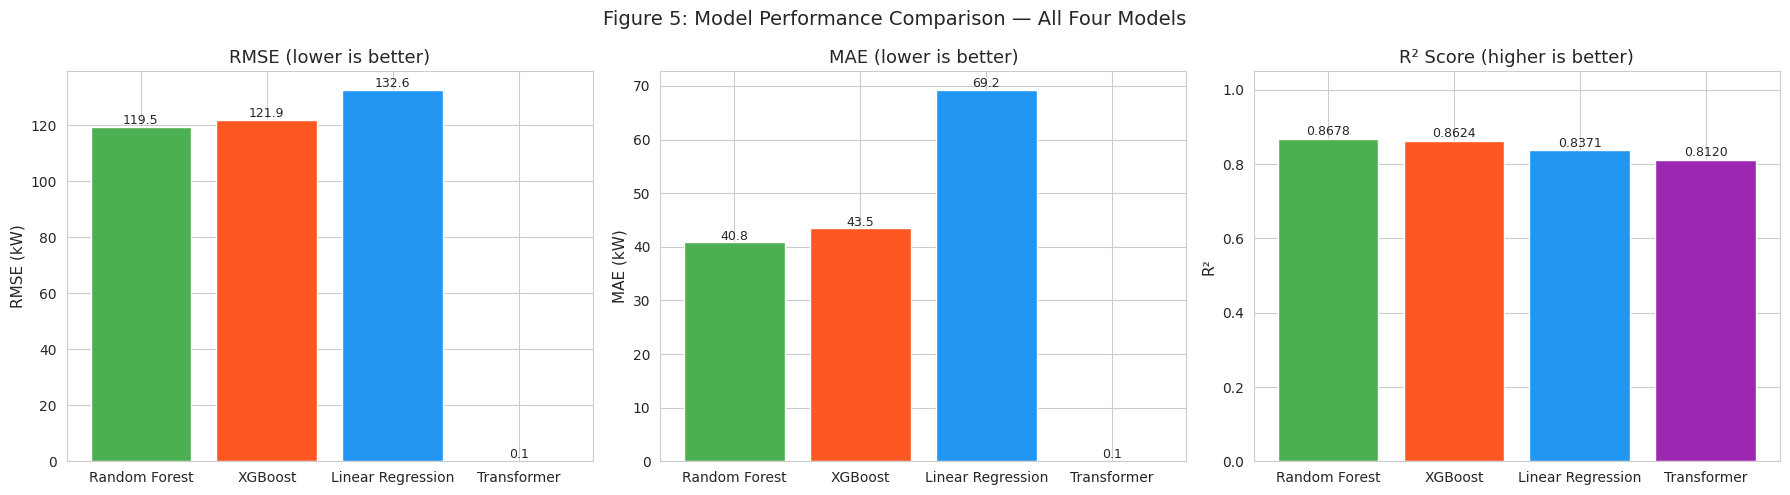

In [28]:
colors = ['#4CAF50', '#FF5722', '#2196F3', '#9C27B0']
models = results_df['Model'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(models, results_df['RMSE'], color=colors)
axes[0].set_title('RMSE (lower is better)'); axes[0].set_ylabel('RMSE (kW)')
for i, v in enumerate(results_df['RMSE']): axes[0].text(i, v + 1, f'{v:,.1f}', ha='center', fontsize=9)

axes[1].bar(models, results_df['MAE'], color=colors)
axes[1].set_title('MAE (lower is better)'); axes[1].set_ylabel('MAE (kW)')
for i, v in enumerate(results_df['MAE']): axes[1].text(i, v + 0.5, f'{v:,.1f}', ha='center', fontsize=9)

axes[2].bar(models, results_df['R2'], color=colors)
axes[2].set_title('R² Score (higher is better)'); axes[2].set_ylabel('R²'); axes[2].set_ylim(0, 1.05)
for i, v in enumerate(results_df['R2']): axes[2].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Figure 5: Model Performance Comparison — All Four Models', fontsize=14)
plt.tight_layout()
plt.savefig('fig5_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Predicted vs Actual — Figure 6

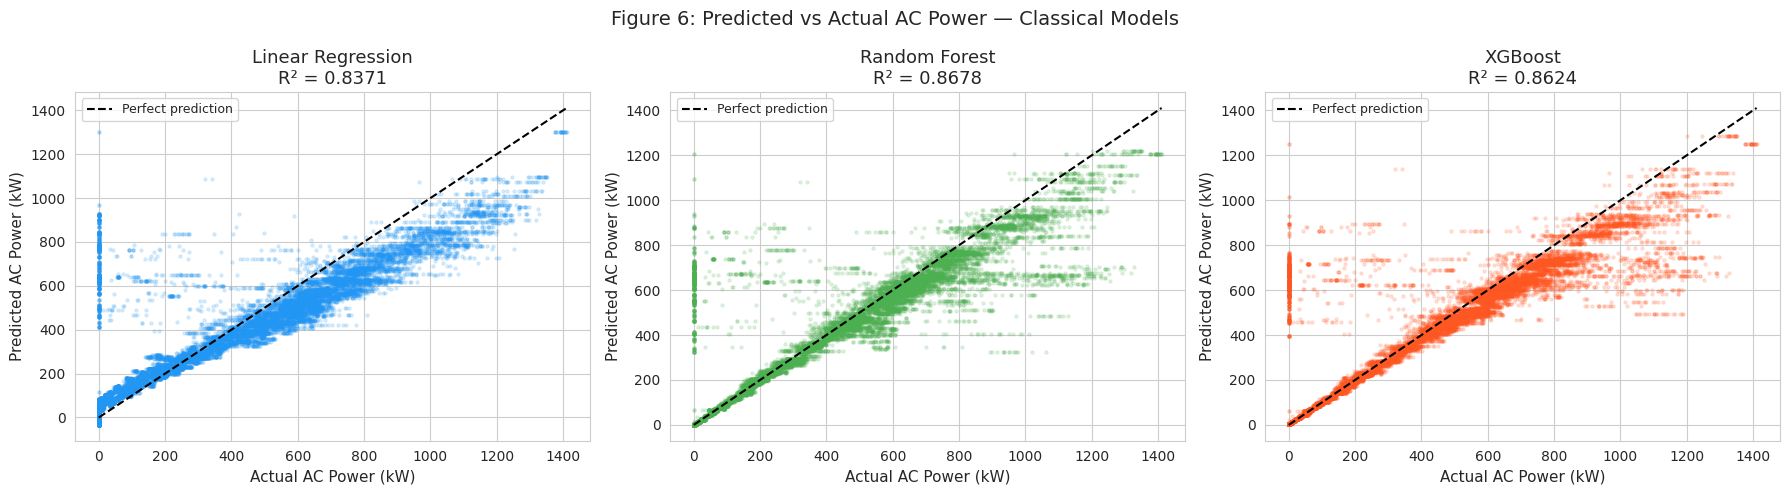

In [29]:
preds_classical = [
    ('Linear Regression', lr_pred,  '#2196F3'),
    ('Random Forest',     rf_pred,  '#4CAF50'),
    ('XGBoost',           xgb_pred, '#FF5722'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, yp, color) in zip(axes, preds_classical):
    ax.scatter(y_test, yp, alpha=0.15, s=5, color=color)
    mv = max(float(np.array(y_test).max()), float(np.array(yp).max()))
    ax.plot([0, mv], [0, mv], 'k--', linewidth=1.5, label='Perfect prediction')
    ax.set_title(f'{name}\nR² = {r2_score(y_test, yp):.4f}')
    ax.set_xlabel('Actual AC Power (kW)'); ax.set_ylabel('Predicted AC Power (kW)')
    ax.legend(fontsize=9)

plt.suptitle('Figure 6: Predicted vs Actual AC Power — Classical Models', fontsize=14)
plt.tight_layout()
plt.savefig('fig6_pred_actual.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Residual Plots — Figure 7

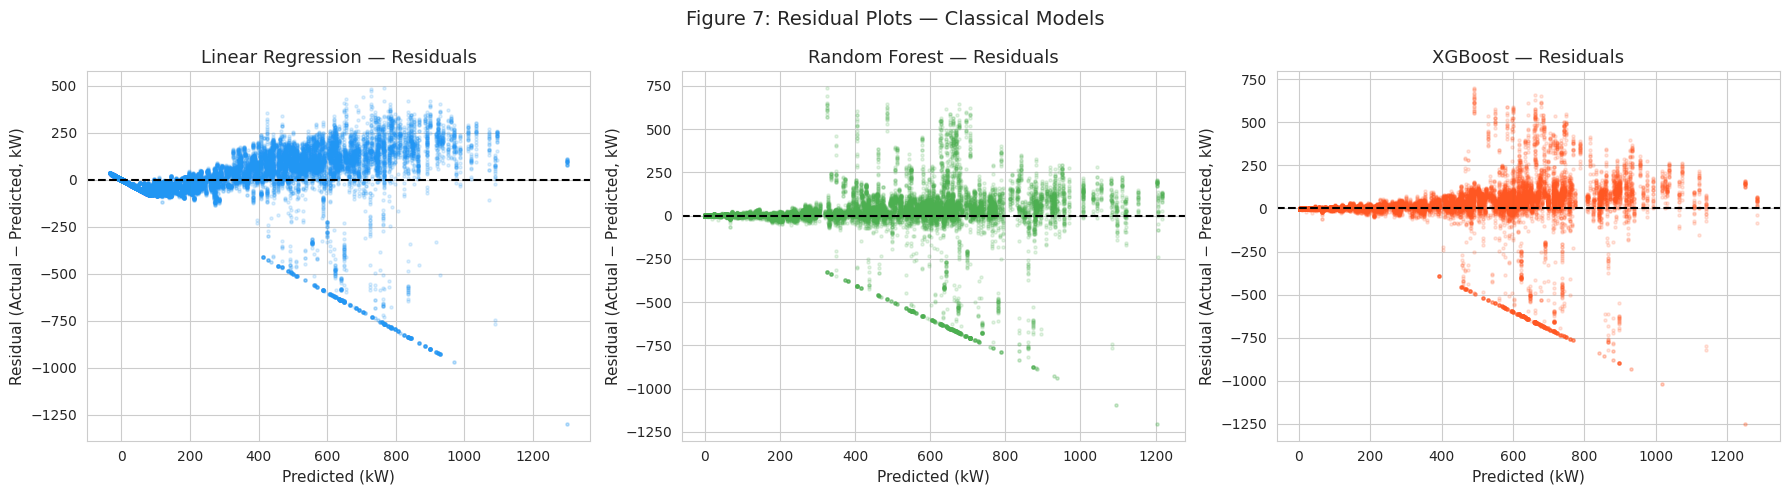

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, yp, color) in zip(axes, preds_classical):
    residuals = np.array(y_test) - np.array(yp)
    ax.scatter(yp, residuals, alpha=0.15, s=5, color=color)
    ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
    ax.set_title(f'{name} — Residuals')
    ax.set_xlabel('Predicted (kW)'); ax.set_ylabel('Residual (Actual − Predicted, kW)')

plt.suptitle('Figure 7: Residual Plots — Classical Models', fontsize=14)
plt.tight_layout()
plt.savefig('fig7_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Random Forest Feature Importances — Figure 8

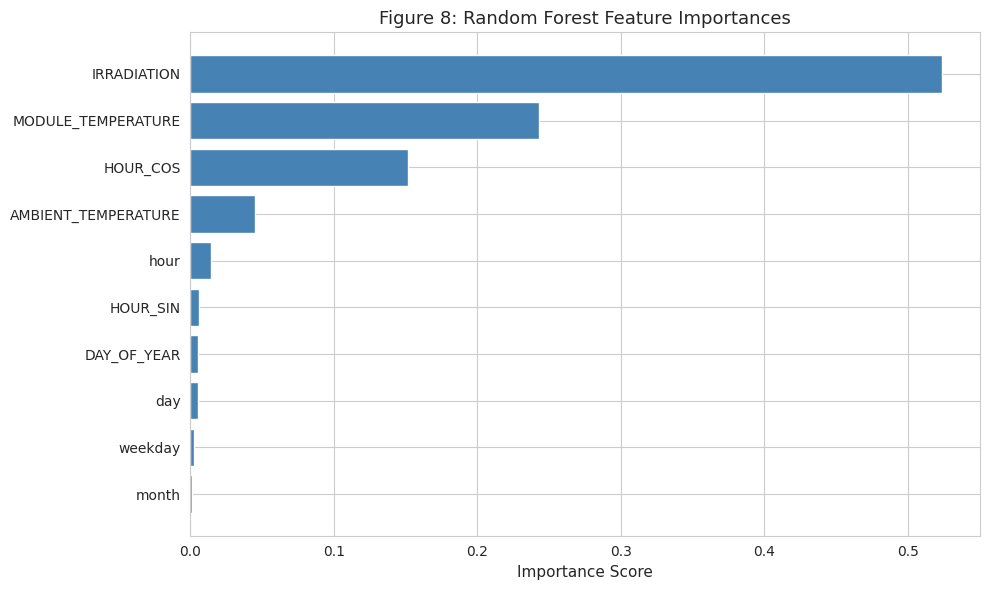


Top 5 features:


,Feature,Importance
2,IRRADIATION,0.524150
1,MODULE_TEMPERATURE,0.243166
4,HOUR_COS,0.152006
0,AMBIENT_TEMPERATURE,0.045382
6,hour,0.014463


In [31]:
importance = rf_model.feature_importances_
feature_df = pd.DataFrame({'Feature': features, 'Importance': importance})
feature_df = feature_df.sort_values('Importance', ascending=False)

fi_sorted = feature_df.sort_values('Importance')
plt.figure(figsize=(10, 6))
plt.barh(fi_sorted['Feature'], fi_sorted['Importance'], color='steelblue')
plt.title('Figure 8: Random Forest Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('fig8_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 features:')
display(feature_df.head())

### 5.6 Learning Curves — Random Forest — Figure 9

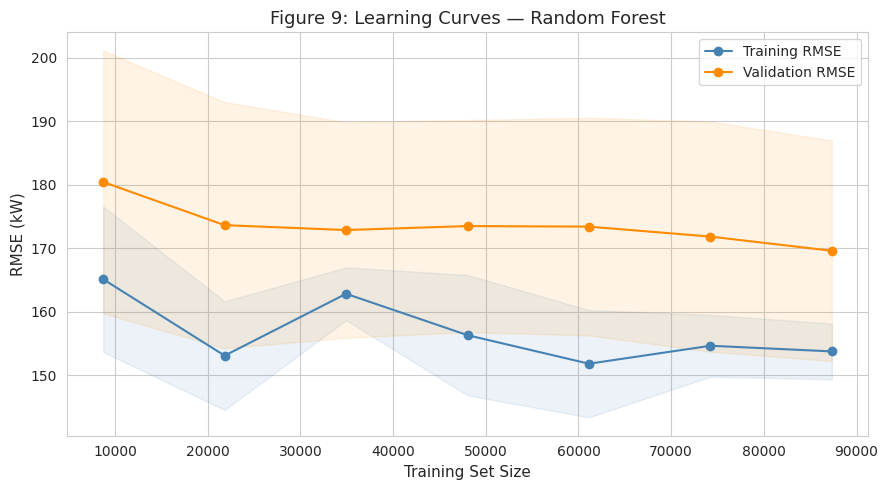

In [32]:
train_sizes, tr_scores, vl_scores = learning_curve(
    rf_model, x_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 7),
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
)
tr_rmse = -tr_scores.mean(axis=1); tr_std = tr_scores.std(axis=1)
vl_rmse = -vl_scores.mean(axis=1); vl_std = vl_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, tr_rmse, 'o-', color='steelblue',  label='Training RMSE')
plt.plot(train_sizes, vl_rmse, 'o-', color='darkorange', label='Validation RMSE')
plt.fill_between(train_sizes, tr_rmse-tr_std, tr_rmse+tr_std, alpha=0.1, color='steelblue')
plt.fill_between(train_sizes, vl_rmse-vl_std, vl_rmse+vl_std, alpha=0.1, color='darkorange')
plt.title('Figure 9: Learning Curves — Random Forest')
plt.xlabel('Training Set Size'); plt.ylabel('RMSE (kW)'); plt.legend()
plt.tight_layout()
plt.savefig('fig9_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.6b Time-Series Prediction Sample — Figure 10


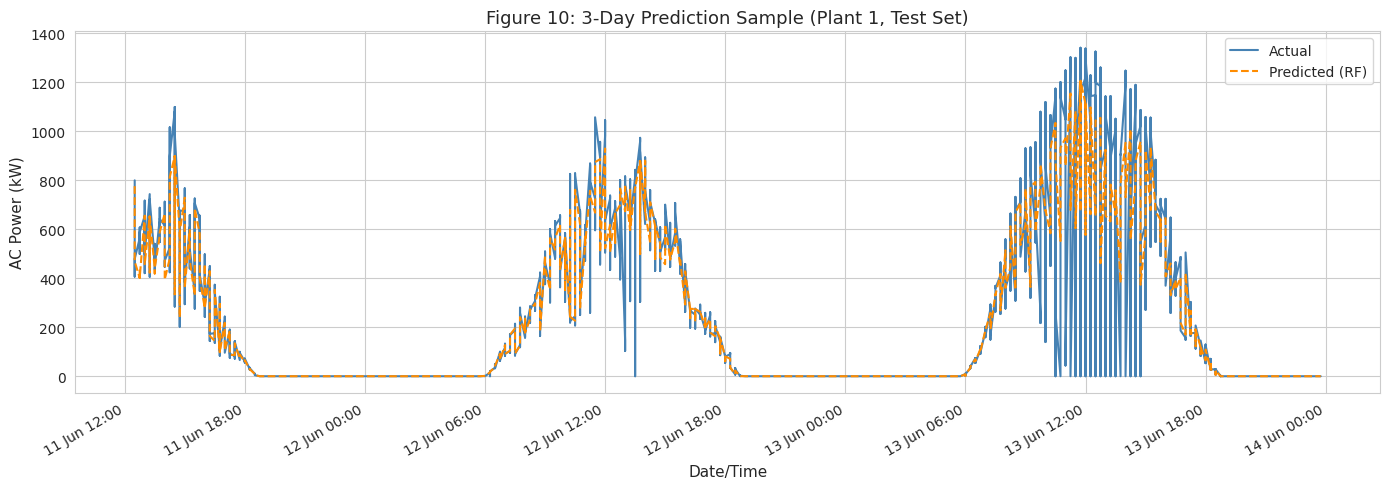

In [33]:
# 3-day time-series comparison — Plant 1 (first 3 test days)
import matplotlib.dates as mdates

# Get Plant 1 test data only
test_data = data.iloc[split_idx:].copy()
test_data_p1 = test_data[test_data['PLANT'] == 1].copy() if 'PLANT' in test_data.columns else test_data.copy()
test_data_p1 = test_data_p1.sort_values('DATE_TIME')

# Restrict to first 3 days of test set
start_date = test_data_p1['DATE_TIME'].min().date()
end_date   = start_date + pd.Timedelta(days=3)
mask = (test_data_p1['DATE_TIME'].dt.date >= start_date) & (test_data_p1['DATE_TIME'].dt.date < end_date)
sample     = test_data_p1[mask].copy()

# Get Random Forest predictions for the full test set
rf_pred_series = pd.Series(rf_pred, index=test_data.index)
sample_pred    = rf_pred_series.loc[sample.index]

plt.figure(figsize=(14, 5))
plt.plot(sample['DATE_TIME'], sample['AC_POWER'], color='steelblue',  linewidth=1.5, label='Actual')
plt.plot(sample['DATE_TIME'], sample_pred.values, color='darkorange', linewidth=1.5, linestyle='--', label='Predicted (RF)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.gcf().autofmt_xdate(rotation=30)
plt.title('Figure 10: 3-Day Prediction Sample (Plant 1, Test Set)')
plt.xlabel('Date/Time'); plt.ylabel('AC Power (kW)')
plt.legend(); plt.tight_layout()
plt.savefig('fig10_3day_prediction.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.7 Transformer Training Loss — Figure 11

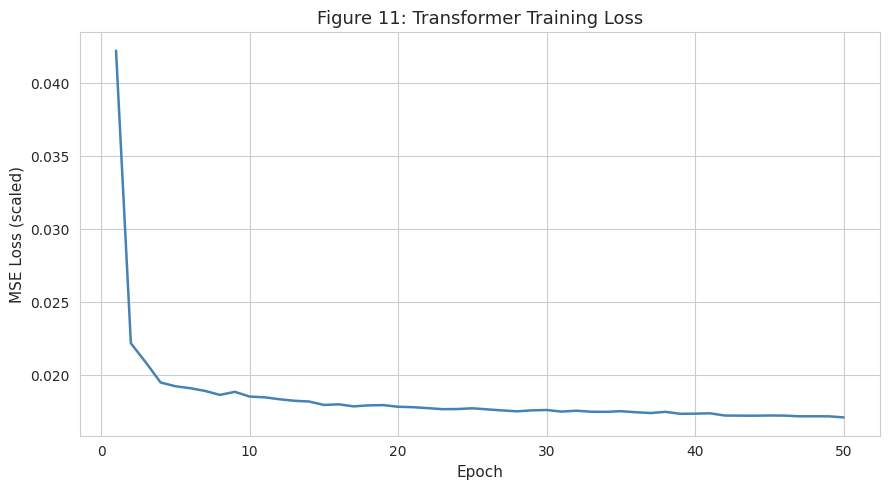

In [34]:
plt.figure(figsize=(9, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, color='steelblue', linewidth=1.8)
plt.title('Figure 11: Transformer Training Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss (scaled)')
plt.tight_layout()
plt.savefig('fig11_transformer_loss.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.8 Transformer Predicted vs Actual + Full R² Comparison — Figure 12

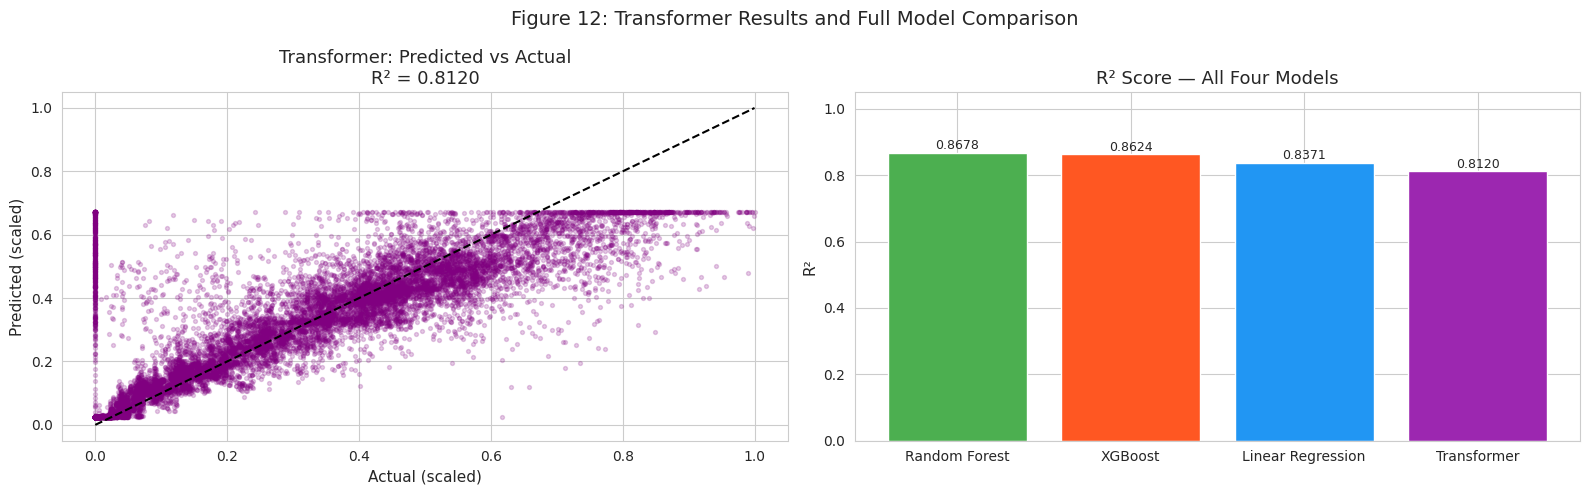

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Transformer scatter (scaled values)
y_te_np = y_test_seq.ravel()
y_tf_np = transformer_pred.numpy().ravel()

axes[0].scatter(y_te_np, y_tf_np, alpha=0.2, s=8, color='purple')
mv = max(float(y_te_np.max()), float(y_tf_np.max()))
axes[0].plot([0, mv], [0, mv], 'k--', linewidth=1.5)
axes[0].set_title(f'Transformer: Predicted vs Actual\nR² = {r2_score(y_te_np, y_tf_np):.4f}')
axes[0].set_xlabel('Actual (scaled)'); axes[0].set_ylabel('Predicted (scaled)')

# All-model R² comparison
r2s = results_df.sort_values('R2', ascending=False)
bar_colors = ['#4CAF50', '#FF5722', '#2196F3', '#9C27B0']
axes[1].bar(r2s['Model'], r2s['R2'], color=bar_colors)
axes[1].set_title('R² Score — All Four Models')
axes[1].set_ylabel('R²'); axes[1].set_ylim(0, 1.05)
for i, v in enumerate(r2s['R2']): axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Figure 12: Transformer Results and Full Model Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('fig11_transformer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.9 Transformer Residual Analysis — Figure 13

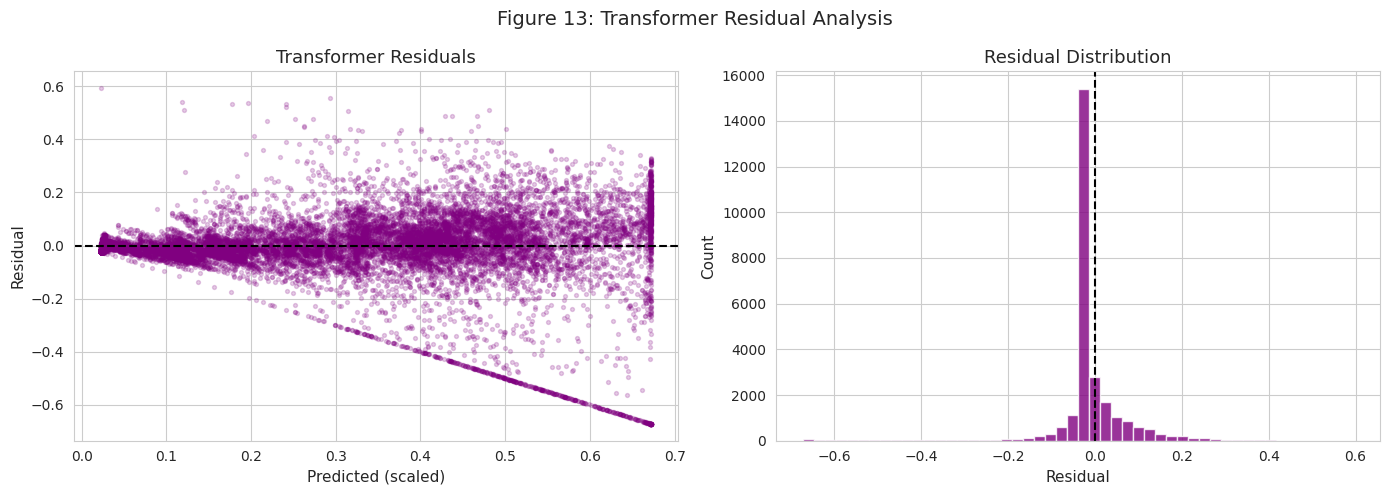

In [36]:
tf_residuals = y_test_seq.ravel() - transformer_pred.numpy().ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_tf_np, tf_residuals, alpha=0.2, s=8, color='purple')
axes[0].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[0].set_title('Transformer Residuals')
axes[0].set_xlabel('Predicted (scaled)'); axes[0].set_ylabel('Residual')

axes[1].hist(tf_residuals, bins=50, color='purple', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_title('Residual Distribution'); axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Count')

plt.suptitle('Figure 13: Transformer Residual Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('fig13_transformer_residuals.png', dpi=150, bbox_inches='tight')
plt.show()